# PaySim Data Preparation and Exploratory Analysis

This notebook is part of the ordered PaySim fraud-detection workflow. See the project README for data setup, evaluation context, and limitations.

## 1. Imports


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path('../data/raw/paysim1.zip')
RAW_FILE = 'PS_20174392719_1491204439457_log.csv'
ROW_LIMIT = 800_000
PROCESSED_DIR = Path('../data/processed')


# 2. Load dataset

We load the PaySim dataset.


In [2]:
with zipfile.ZipFile(DATA_PATH) as zf:
    with zf.open(RAW_FILE) as raw_file:
        paysim_df = pd.read_csv(raw_file, nrows=ROW_LIMIT)

print(f"Loaded {len(paysim_df):,} rows from {DATA_PATH}.")
paysim_df.head()


Loaded 800,000 rows from ../data/raw/paysim1.zip.


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0


# 3. Quick data check

We check the shape, columns, first few rows and data types.


In [3]:
print("Shape:", paysim_df.shape)
print()
print("Columns:")
print(paysim_df.columns.tolist())
print()
paysim_df.info()

paysim_df.head()


Shape: (800000, 11)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            800000 non-null  int64  
 1   type            800000 non-null  object 
 2   amount          800000 non-null  float64
 3   nameOrig        800000 non-null  object 
 4   oldbalanceOrg   800000 non-null  float64
 5   newbalanceOrig  800000 non-null  float64
 6   nameDest        800000 non-null  object 
 7   oldbalanceDest  800000 non-null  float64
 8   newbalanceDest  800000 non-null  float64
 9   isFraud         800000 non-null  int64  
 10  isFlaggedFraud  800000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 67.1+ MB


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0


# 4. Missing values and duplicates

We check if there are any missing values or duplicate rows.


In [4]:
print("Missing values per column:")
print(paysim_df.isnull().sum())
print()
print(f"Duplicate rows: {paysim_df.duplicated().sum():,}")


Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0


# 5. Class balance

We check how many fraud and non-fraud transactions there are.


Class distribution:
isFraud
0    799540
1       460
Name: count, dtype: int64

Fraud rate: 0.0575%
Imbalance ratio (legit:fraud): 1738 : 1


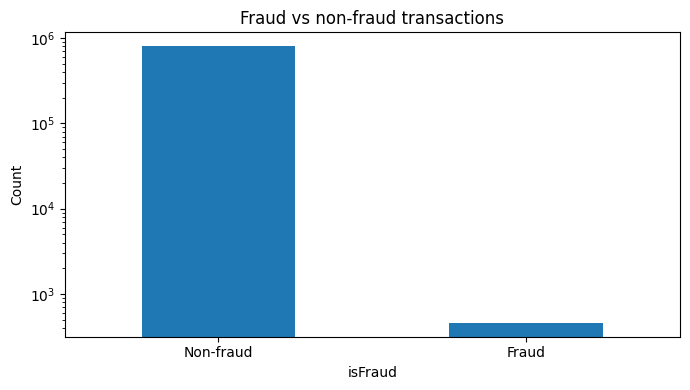

In [5]:
fraud_counts = paysim_df['isFraud'].value_counts()
fraud_pct = paysim_df['isFraud'].value_counts(normalize=True) * 100

print("Class distribution:")
print(fraud_counts)
print()
print(f"Fraud rate: {fraud_pct[1]:.4f}%")
print(f"Imbalance ratio (legit:fraud): {fraud_counts[0] / fraud_counts[1]:.0f} : 1")

fig, ax = plt.subplots(figsize=(7, 4))
fraud_counts.plot(kind='bar', ax=ax)
ax.set_title('Fraud vs non-fraud transactions')
ax.set_xlabel('isFraud')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.set_xticklabels(['Non-fraud', 'Fraud'], rotation=0)
plt.tight_layout()
plt.show()


# 6. Transaction types

We check which transaction types contain fraud.


Transaction type counts:
type
CASH_OUT    287703
PAYMENT     265900
CASH_IN     174973
TRANSFER     66011
DEBIT         5413
Name: count, dtype: int64

Fraud by type:
          Fraud count  Total transactions  Fraud rate  Fraud rate %
type                                                               
TRANSFER          222               66011        0.00          0.34
CASH_OUT          238              287703        0.00          0.08
CASH_IN             0              174973        0.00          0.00
DEBIT               0                5413        0.00          0.00
PAYMENT             0              265900        0.00          0.00


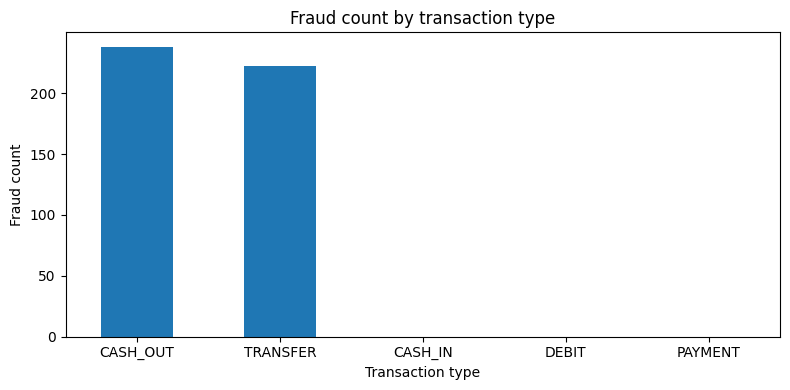

In [6]:
type_counts = paysim_df['type'].value_counts()
print("Transaction type counts:")
print(type_counts)

fraud_by_type = paysim_df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean'])
fraud_by_type.columns = ['Fraud count', 'Total transactions', 'Fraud rate']
fraud_by_type['Fraud rate %'] = fraud_by_type['Fraud rate'] * 100
print()
print("Fraud by type:")
print(fraud_by_type.sort_values('Fraud rate', ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
fraud_by_type['Fraud count'].sort_values(ascending=False).plot(kind='bar', ax=ax)
ax.set_title('Fraud count by transaction type')
ax.set_xlabel('Transaction type')
ax.set_ylabel('Fraud count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


# 7. Amount patterns

We compare transaction amounts for fraud and non-fraud cases.


Median amount - non-fraud: 79,711.06
Median amount - fraud:     235,375.43


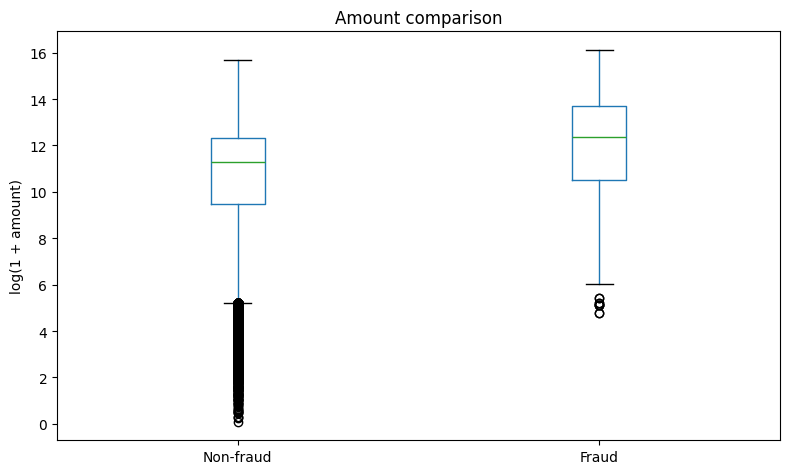

In [7]:
amount_compare = paysim_df.assign(log_amount=np.log1p(paysim_df['amount']))

fig, ax = plt.subplots(figsize=(8, 5))
amount_compare.boxplot(column='log_amount', by='isFraud', ax=ax, grid=False)
fig.suptitle('')
ax.set_xticklabels(['Non-fraud', 'Fraud'])
ax.set_xlabel('')
ax.set_ylabel('log(1 + amount)')
ax.set_title('Amount comparison')
plt.tight_layout()
plt.show()

print("Median amount - non-fraud: {:,.2f}".format(
    paysim_df.loc[paysim_df['isFraud'] == 0, 'amount'].median()))
print("Median amount - fraud:     {:,.2f}".format(
    paysim_df.loc[paysim_df['isFraud'] == 1, 'amount'].median()))


# 8. isFlaggedFraud check

We check the existing rule flag, but we do not use it as a main feature.


In [8]:
flagged_vs_real = pd.crosstab(
    paysim_df['isFlaggedFraud'], paysim_df['isFraud'],
    rownames=['Rule flagged'], colnames=['Actually fraud'],
    margins=True
)
print(flagged_vs_real)

flagged_total = paysim_df['isFlaggedFraud'].sum()
fraud_total = paysim_df['isFraud'].sum()
flagged_and_fraud = ((paysim_df['isFlaggedFraud'] == 1) & (paysim_df['isFraud'] == 1)).sum()

print()
print(f"Rule flags: {flagged_total} transactions in total")
print(f"Of {fraud_total} actual frauds, the rule catches {flagged_and_fraud}")
print(f"Rule recall: {flagged_and_fraud / fraud_total:.4%}")


Actually fraud       0    1     All
Rule flagged                       
0               799540  460  800000
All             799540  460  800000

Rule flags: 0 transactions in total
Of 460 actual frauds, the rule catches 0
Rule recall: 0.0000%


# 9. Filter data

Fraud only appears in TRANSFER and CASH_OUT, so we keep only those transaction types.


In [9]:
print(f"Before filtering: {len(paysim_df):,} rows | fraud rate {paysim_df['isFraud'].mean()*100:.4f}%")

paysim_df = paysim_df[paysim_df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy().reset_index(drop=True)

print(f"After filtering:  {len(paysim_df):,} rows | fraud rate {paysim_df['isFraud'].mean()*100:.4f}%")
print(f"New imbalance ratio: {(paysim_df['isFraud']==0).sum() / (paysim_df['isFraud']==1).sum():.0f} : 1")


Before filtering: 800,000 rows | fraud rate 0.0575%
After filtering:  353,714 rows | fraud rate 0.1300%
New imbalance ratio: 768 : 1


# 10. Drop columns

We drop account IDs and the rule flag.


In [10]:
paysim_df = paysim_df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])
print("Remaining columns:")
print(paysim_df.columns.tolist())

paysim_df.head()


Remaining columns:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
1,1,CASH_OUT,181.00,181.00,0.00,"21,182.00",0.00,1
2,1,CASH_OUT,"229,133.94","15,325.00",0.00,"5,083.00","51,513.44",0
3,1,TRANSFER,"215,310.30",705.00,0.00,"22,425.00",0.00,0
4,1,TRANSFER,"311,685.89","10,835.00",0.00,"6,267.00","2,719,172.89",0


# 11. Feature engineering

We create balance features because fraud may show unusual balance movement.


In [11]:
paysim_df['sender_balance_error'] = (
    paysim_df['oldbalanceOrg'] - paysim_df['amount'] - paysim_df['newbalanceOrig']
)
paysim_df['receiver_balance_error'] = (
    paysim_df['oldbalanceDest'] + paysim_df['amount'] - paysim_df['newbalanceDest']
)
paysim_df['sender_balance_change'] = (
    paysim_df['oldbalanceOrg'] - paysim_df['newbalanceOrig']
)
paysim_df['receiver_balance_change'] = (
    paysim_df['newbalanceDest'] - paysim_df['oldbalanceDest']
)
paysim_df['amount_to_balance_ratio'] = (
    paysim_df['amount'] / (paysim_df['oldbalanceOrg'] + 1)
)

engineered = [
    'sender_balance_error',
    'receiver_balance_error',
    'sender_balance_change',
    'receiver_balance_change',
    'amount_to_balance_ratio'
]

print(paysim_df.groupby('isFraud')[engineered].median().T)
paysim_df[['amount', 'sender_balance_error', 'receiver_balance_error',
           'amount_to_balance_ratio', 'isFraud']].head()


isFraud                           0          1
sender_balance_error    -150,636.02       0.00
receiver_balance_error         0.00   8,515.25
sender_balance_change        283.00 212,089.74
receiver_balance_change  209,968.11   7,613.94
amount_to_balance_ratio      650.65       1.00


,amount,sender_balance_error,receiver_balance_error,amount_to_balance_ratio,isFraud
0,181.00,0.00,181.00,0.99,1
1,181.00,0.00,"21,363.00",0.99,1
2,"229,133.94","-213,808.94","182,703.50",14.95,0
3,"215,310.30","-214,605.30","237,735.30",304.97,0
4,"311,685.89","-300,850.89","-2,401,220.00",28.76,0


# 12. Encode type

We one-hot encode the type column so the models can use it.


In [12]:
paysim_df = pd.get_dummies(paysim_df, columns=['type'], drop_first=False)
paysim_df.head()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,sender_balance_error,receiver_balance_error,sender_balance_change,receiver_balance_change,amount_to_balance_ratio,type_CASH_OUT,type_TRANSFER
0,1,181.00,181.00,0.00,0.00,0.00,1,0.00,181.00,181.00,0.00,0.99,False,True
1,1,181.00,181.00,0.00,"21,182.00",0.00,1,0.00,"21,363.00",181.00,"-21,182.00",0.99,True,False
2,1,"229,133.94","15,325.00",0.00,"5,083.00","51,513.44",0,"-213,808.94","182,703.50","15,325.00","46,430.44",14.95,True,False
3,1,"215,310.30",705.00,0.00,"22,425.00",0.00,0,"-214,605.30","237,735.30",705.00,"-22,425.00",304.97,False,True
4,1,"311,685.89","10,835.00",0.00,"6,267.00","2,719,172.89",0,"-300,850.89","-2,401,220.00","10,835.00","2,712,905.89",28.76,False,True


# 13. Correlation check

We check which features have the strongest relationship with isFraud.


Correlation with isFraud:
isFraud                    1.00
sender_balance_change      0.30
oldbalanceOrg              0.15
amount                     0.07
receiver_balance_error     0.03
type_TRANSFER              0.03
sender_balance_error       0.02
receiver_balance_change    0.01
newbalanceOrig             0.00
step                      -0.00
newbalanceDest            -0.01
oldbalanceDest            -0.01
amount_to_balance_ratio   -0.02
type_CASH_OUT             -0.03
Name: isFraud, dtype: float64


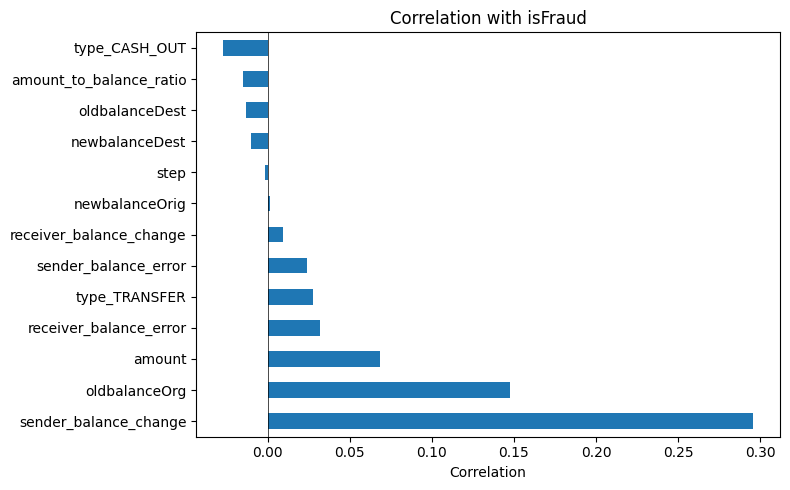

In [13]:
corr_with_target = paysim_df.corr()['isFraud'].sort_values(ascending=False)
print("Correlation with isFraud:")
print(corr_with_target)

fig, ax = plt.subplots(figsize=(8, 5))
corr_with_target.drop('isFraud').plot(kind='barh', ax=ax)
ax.set_title('Correlation with isFraud')
ax.set_xlabel('Correlation')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


# 14. Train/test split

We split the data before scaling to avoid data leakage.


In [14]:
y = paysim_df['isFraud']
X = paysim_df.drop(columns=['isFraud'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training set: {X_train.shape[0]:,} rows | fraud rate {y_train.mean()*100:.4f}%")
print(f"Test set:     {X_test.shape[0]:,} rows | fraud rate {y_test.mean()*100:.4f}%")


Training set: 282,971 rows | fraud rate 0.1300%
Test set:     70,743 rows | fraud rate 0.1300%


# 15. Standardisation

We standardise numeric features using the training data only.


In [15]:
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest',
                'sender_balance_error', 'receiver_balance_error',
                'sender_balance_change', 'receiver_balance_change',
                'amount_to_balance_ratio']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaled numeric columns:")
print(X_train[numeric_cols].mean().round(3))


Scaled numeric columns:
step                       0.00
amount                     0.00
oldbalanceOrg              0.00
newbalanceOrig            -0.00
oldbalanceDest             0.00
newbalanceDest            -0.00
sender_balance_error      -0.00
receiver_balance_error    -0.00
sender_balance_change     -0.00
receiver_balance_change    0.00
amount_to_balance_ratio    0.00
dtype: float64


# 16. Save processed data

We save the train and test files for the model notebooks.


In [16]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

X_train.to_csv(PROCESSED_DIR / 'X_train.csv', index=False)
X_test.to_csv(PROCESSED_DIR / 'X_test.csv', index=False)
y_train.to_csv(PROCESSED_DIR / 'y_train.csv', index=False)
y_test.to_csv(PROCESSED_DIR / 'y_test.csv', index=False)

print(f"Saved files to {PROCESSED_DIR}/")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")


Saved files to ../data/processed/
X_train: (282971, 13)
X_test:  (70743, 13)
y_train: (282971,)
y_test:  (70743,)
